# Semi-synthetic event-distribution sanity check

This follows `survival-copula/notebooks/plot_event_distribution.ipynb` as closely as possible: each dataset panel combines a Kaplan–Meier curve with a stacked event/censoring histogram. The source cohort and the deterministic semi-synthetic draw are overlaid using shared bins, so their marginal observed-time distributions can be checked directly.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import yaml
from lifelines import KaplanMeierFitter

from experiments.config import expand_seed_streams, semisynthetic_datasets
from utility.semisynthetic import fit_semisynthetic_dgp, generate_semisynthetic

plt.style.use("default")
plt.rcParams.update({"axes.labelsize": "medium", "axes.titlesize": "medium", "font.size": 14.0})
sns.set_style("whitegrid")
colors = sns.color_palette("deep")

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
CONFIG_PATH = ROOT / "configs" / "semi_synthetic.yaml"
with CONFIG_PATH.open(encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

c:\Users\cml\miniconda3\envs\dvfm\Lib\site-packages\lifelines\utils\__init__.py:1120: ConvergenceWarning: Column chapter_Circulatory have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['event'].astype(bool)
>>> print(df.loc[events, 'chapter_Circulatory'].var())
>>> print(df.loc[~events, 'chapter_Circulatory'].var())

A very low variance means that the column chapter_Circulatory completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
c:\Users\cml\miniconda3\envs\dvfm\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthed

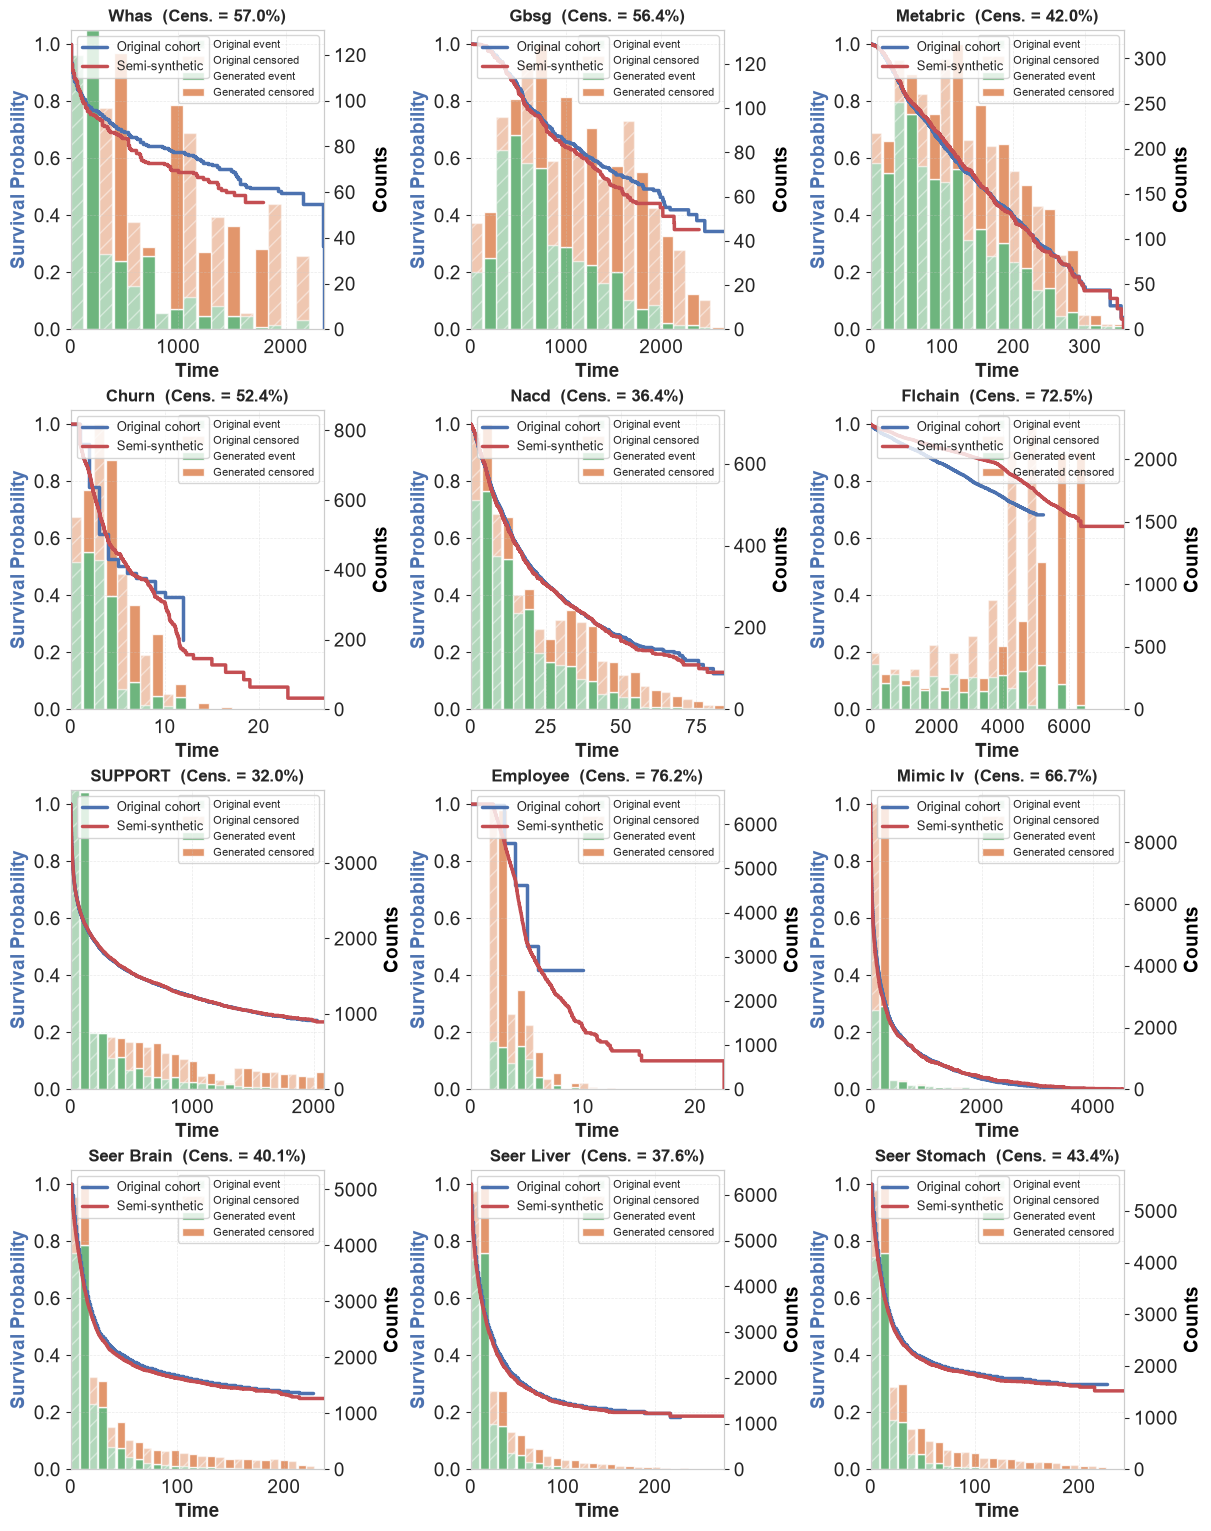

Saved: c:\Users\cml\Desktop\dvfm-survival\paper\figures\semi_synthetic_event_distribution_clayton_tau_0.5_censor_source_repeat_0.pdf


In [2]:
# Select one generated condition. These settings recreate the same draw used by the runner.
COPULA = "clayton"
TARGET_TAU = 0.50
TARGET_CENSORING = "original"  # Match each source cohort's observed censoring rate.
REPEAT = 0
DATASET_NAMES = None  # None plots every dataset in the YAML; otherwise, e.g. ["support"].

datasets = semisynthetic_datasets(config["data"])
if DATASET_NAMES is not None:
    wanted = {name.lower() for name in DATASET_NAMES}
    datasets = [dataset for dataset in datasets if dataset["name"].lower() in wanted]
if not datasets:
    raise ValueError("No configured datasets matched DATASET_NAMES.")

def map_dataset_name(dataset_name):
    # Keep the paper-facing title convention used by the reference notebook.
    return {"support": "SUPPORT"}.get(dataset_name.lower(), dataset_name.replace("_", " ").title())

seed_stream = expand_seed_streams(config["seeds"])[REPEAT]
n_columns = 3
n_rows = math.ceil(len(datasets) / n_columns)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_columns, figsize=(12, 3.8 * n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for index, dataset in enumerate(datasets):
    # YAML file sources are repository-relative; built-in loaders need no path.
    dataset = dict(dataset)
    if dataset.get("path"):
        source_path = Path(dataset["path"])
        dataset["path"] = str(source_path if source_path.is_absolute() else ROOT / source_path)
    dgp = fit_semisynthetic_dgp(dataset, cox_penalizer=float(config["data"].get("cox_penalizer", 0.01)))
    target_censoring = (
        1.0 - float(dgp.source_event_rate) if TARGET_CENSORING == "original" else float(TARGET_CENSORING)
    )
    generated = generate_semisynthetic(
        dgp, kendall_tau=0, censoring_rate=target_censoring,
        sampling_seed=int(seed_stream["sampling"]), copula=COPULA,
    )
    source_time, source_event = dgp.source_time, dgp.source_event
    generated_time, generated_event = generated.data.time, generated.data.event
    intervals = math.ceil(math.log2(len(generated_time)) + 1)
    maximum = max(source_time.max(), generated_time.max())
    bins = np.linspace(0, maximum, intervals)

    ax0 = axes[index]
    for times, events, label, color in (
        (source_time, source_event, "Original cohort", colors[0]),
        (generated_time, generated_event, "Semi-synthetic", colors[3]),
    ):
        km = KaplanMeierFitter().fit(times, event_observed=events)
        ax0.step(km.survival_function_.index, km.survival_function_.iloc[:, 0],
                 linewidth=2.5, color=color, label=label, where="post", zorder=4)
    ax0.set_ylabel("Survival Probability", color=colors[0], weight="bold")
    ax0.set_xlabel("Time", weight="bold")
    ax0.set_ylim([0, 1.05])
    ax0.set_xlim([0, maximum])
    ax0.grid(visible=True, which="major", linestyle="--", linewidth=0.5, alpha=0.4)

    # Split each common bin into original (hatched, left) and generated
    # (solid, right) stacks. This avoids hiding either distribution.
    source_event_counts, _ = np.histogram(source_time[source_event == 1], bins=bins)
    source_censor_counts, _ = np.histogram(source_time[source_event == 0], bins=bins)
    generated_event_counts, _ = np.histogram(generated_time[generated_event == 1], bins=bins)
    generated_censor_counts, _ = np.histogram(generated_time[generated_event == 0], bins=bins)
    bin_width = np.diff(bins)
    ax1 = ax0.twinx()
    ax1.bar(bins[:-1], source_event_counts, width=0.46 * bin_width, align="edge",
            color=colors[2], alpha=0.45, hatch="//", label="Original event", zorder=2)
    ax1.bar(bins[:-1], source_censor_counts, bottom=source_event_counts, width=0.46 * bin_width, align="edge",
            color=colors[1], alpha=0.45, hatch="//", label="Original censored", zorder=2)
    ax1.bar(bins[:-1] + 0.54 * bin_width, generated_event_counts, width=0.46 * bin_width, align="edge",
            color=colors[2], alpha=0.85, label="Generated event", zorder=2)
    ax1.bar(bins[:-1] + 0.54 * bin_width, generated_censor_counts, bottom=generated_event_counts, width=0.46 * bin_width, align="edge",
            color=colors[1], alpha=0.85, label="Generated censored", zorder=2)
    ax1.set_ylabel("Counts", color="black", weight="bold")
    ax1.yaxis.grid(False)
    ax0.set_zorder(ax1.get_zorder() + 1)
    ax0.patch.set_visible(False)
    ax0.legend(loc="upper left", frameon=True, fontsize=9)
    ax1.legend(loc="upper right", frameon=True, fontsize=8)
    # Add title to each subplot
    dataset_name_display = map_dataset_name(dataset['name'])
    cens_pct = 100 * (1.0 - generated_event.mean())
    ax0.set_title(
        f"{dataset_name_display}  (Cens. = {cens_pct:.1f}%)",
        fontsize=12,
        weight="bold",
    )

for index in range(len(datasets), len(axes)):
    fig.delaxes(axes[index])

censor_label = "source" if TARGET_CENSORING == "original" else f"{float(TARGET_CENSORING):g}"
output = ROOT / "paper" / "figures" / f"semi_synthetic_event_distribution_{COPULA}_tau_{TARGET_TAU:g}_censor_{censor_label}_repeat_{REPEAT}.pdf"
output.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output, format="pdf", bbox_inches="tight")
plt.show()
print(f"Saved: {output}")

Within every time bin, hatched left bars are the original cohort and solid right bars are the generated cohort; event counts are stacked below censored counts. The two Kaplan–Meier curves compare observed survival. The copula should not materially change either fitted marginal target, though it can change the observed-time mixture through event/censor dependence.